# SVM KErnels

In [67]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [68]:
import pandas as pd
from sklearn.datasets import make_circles

# Generate synthetic circular data
X, y = make_circles(n_samples=200, random_state=42)

# Create a DataFrame
df = pd.DataFrame(X, columns=["X1", "X2"])
df["Label"] = y  # Add target as a column

# Display the shape and first few rows
print("Shape:", df.shape)
print(df.head())


Shape: (200, 3)
         X1        X2  Label
0  0.951057 -0.309017      0
1  0.587785  0.809017      0
2 -0.309017  0.951057      0
3 -0.701045 -0.385403      1
4 -0.149905  0.785830      1


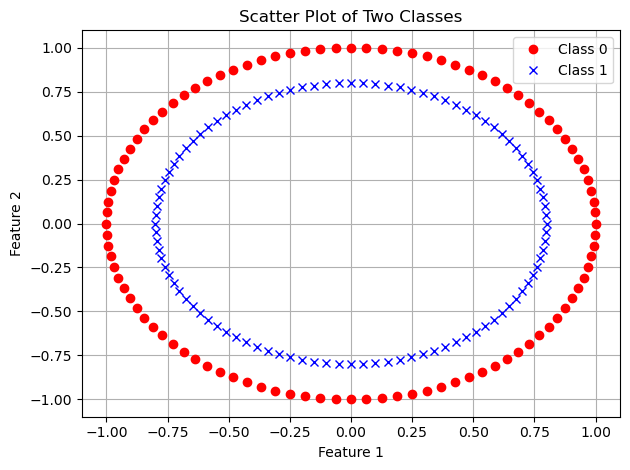

In [69]:
# Plotting the two classes separately using custom markers
# plt.figure(figsize=(6, 6))
plt.plot(X[y == 0][:, 0], X[y == 0][:, 1], "ro", label="Class 0")  # Red circles
plt.plot(X[y == 1][:, 0], X[y == 1][:, 1], "bx", label="Class 1")  # Blue crosses
# sns.scatterplot(X,y,hue=y) based ondataframe
plt.title("Scatter Plot of Two Classes")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


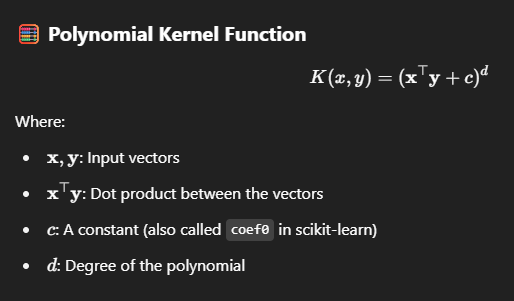

In [70]:
df['X12'] = df["X1"] ** 2
df['X22'] = df["X2"] ** 2
df['X1*X2'] = (df["X2"] * df["X1"])
df["y"] = df["Label"]
df.drop(columns=["Label"], inplace=True)
df.head()

,X1,X2,X12,X22,X1*X2,y
0,0.951057,-0.309017,0.904508,0.095492,-0.293893,0
1,0.587785,0.809017,0.345492,0.654508,0.475528,0
2,-0.309017,0.951057,0.095492,0.904508,-0.293893,0
3,-0.701045,-0.385403,0.491465,0.148535,0.270185,1
4,-0.149905,0.785830,0.022472,0.617528,-0.117800,1


In [71]:
from sklearn.model_selection import train_test_split

# Split features and target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Print the shapes
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)


X_train shape: (140, 5)
X_test shape : (60, 5)
y_train shape: (140,)
y_test shape : (60,)


In [72]:
import plotly.express as px

fig = px.scatter_3d(df, x="X1", y="X2", z="X1*X2", color="y")
fig.show()

In [73]:
import plotly.express as px

fig = px.scatter_3d(df, x="X12", y="X22", z="X1*X2", color="y")
fig.show()

In [74]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

In [ ]:
# 3. Train SVM with polynomial kernel
clf_poly = SVC(kernel='linear', degree=3, C=1.0, gamma='auto', coef0=1)
clf_poly.fit(X_train, y_train)

#  this is same as poly ()
# 4. Predict and evaluateinternally cretae the x12 and x22 and x1*x2)
y_pred = clf_poly.predict(X_test)
print("📊 Classification Report:")
print(classification_report(y_test, y_pred))
print("✅ Accuracy:", accuracy_score(y_test, y_pred))

📊 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        32
           1       1.00      1.00      1.00        28

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60

✅ Accuracy: 1.0


In [76]:
# 3. Train SVM with polynomial kernel
clf_poly = SVC(kernel='poly', degree=3, C=1.0, gamma='auto', coef0=1)
clf_poly.fit(X_train, y_train)

# 4. Predict and evaluate
y_pred = clf_poly.predict(X_test)
print("📊 Classification Report:")
print(classification_report(y_test, y_pred))
print("✅ Accuracy:", accuracy_score(y_test, y_pred))

📊 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        32
           1       1.00      1.00      1.00        28

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60

✅ Accuracy: 1.0
